<a href="https://colab.research.google.com/github/an1khusain/anik/blob/main/Final_Project_of_FND.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

news = pd.read_csv('news_1.csv')
news.head()

,Unnamed: 0,title,text,label
0,0,A whirlwind day in D.C. showcases Trump’s unor...,Donald Trump endorsed an unabashedly noninterv...,REAL
1,1,"In Baltimore's call for federal police probe, ...",While some Justice Department investigations a...,REAL
2,2,Trump Proudly Declares: Most Of The People I’v...,Trump Proudly Declares: Most Of The People I’v...,FAKE
3,3,Inside the Trump-Bush melodrama: Decades of te...,Donald Trump spent a day in January 2014 hobno...,REAL
4,4,Shutdown clash to return in force by December,Notable names include Ray Washburne (Commerce)...,REAL


In [ ]:
news['label'] = news['label'].map({'FAKE': 0, 'REAL': 1})
news.head()

,Unnamed: 0,title,text,label
0,0,A whirlwind day in D.C. showcases Trump’s unor...,Donald Trump endorsed an unabashedly noninterv...,1
1,1,"In Baltimore's call for federal police probe, ...",While some Justice Department investigations a...,1
2,2,Trump Proudly Declares: Most Of The People I’v...,Trump Proudly Declares: Most Of The People I’v...,0
3,3,Inside the Trump-Bush melodrama: Decades of te...,Donald Trump spent a day in January 2014 hobno...,1
4,4,Shutdown clash to return in force by December,Notable names include Ray Washburne (Commerce)...,1


In [ ]:
news = news.drop(['title', 'Unnamed: 0'], axis=1)
news.head()

,text,label
0,Donald Trump endorsed an unabashedly noninterv...,1
1,While some Justice Department investigations a...,1
2,Trump Proudly Declares: Most Of The People I’v...,0
3,Donald Trump spent a day in January 2014 hobno...,1
4,Notable names include Ray Washburne (Commerce)...,1


In [ ]:
import spacy

nlp = spacy.load('en_core_web_sm')

In [ ]:
def preprocess_text(text):
    # Process text using spaCy
    doc = nlp(text)

    # Tokenize, remove stop words, punctuation, and lemmatize
    tokens = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct]

    return tokens

# Apply the function to each row of the 'text' column
news['tokens'] = news['text'].apply(preprocess_text) # Applying the function to each row using apply

# Now, 'news' DataFrame has a new 'tokens' column containing processed tokens for each text

In [ ]:
news['vector'] = news['tokens'].apply(lambda tokens: nlp(" ".join(tokens)).vector)
news.head()

,text,label,tokens,vector
0,Donald Trump endorsed an unabashedly noninterv...,1,"[Donald, Trump, endorse, unabashedly, noninter...","[-0.0650326, -0.73896736, -0.06587156, 0.06816..."
1,While some Justice Department investigations a...,1,"[Justice, Department, investigation, adversari...","[-0.04494511, -0.6944129, -0.0349795, 0.083546..."
2,Trump Proudly Declares: Most Of The People I’v...,0,"[Trump, Proudly, declare, People, insult, Dese...","[-0.038408447, -0.7297724, -0.036206115, 0.104..."
3,Donald Trump spent a day in January 2014 hobno...,1,"[Donald, Trump, spend, day, January, 2014, hob...","[-0.1550017, -0.74305403, -0.04557736, 0.10435..."
4,Notable names include Ray Washburne (Commerce)...,1,"[notable, name, include, Ray, Washburne, Comme...","[-0.24279524, -0.7967149, -0.07141565, 0.39236..."


In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    news.vector.values,
    news.label,
    test_size=0.2)

In [ ]:
x_train_2D = np.vstack(x_train)
x_test_2D = np.vstack(x_test)

In [ ]:
x_train

array([array([-0.10476013, -0.708465  , -0.23472239,  0.170253  ,  0.03878995,
              -0.16504183,  0.17595264,  0.7532424 ,  0.2199737 , -0.21861331,
              -0.20148326,  0.2137039 , -0.4020277 , -0.31174964, -0.16910076,
               0.2181211 , -0.14691609, -0.08080966, -0.63586056, -0.21986008,
              -0.03595778,  0.7569199 , -0.22867174,  0.1379549 ,  0.1344314 ,
              -0.082132  ,  0.2684505 ,  0.47073784,  0.22999048, -0.09686913,
               0.2148348 , -0.08111656, -0.23402824,  0.15152448,  0.11111418,
              -0.12455607,  0.32609499, -0.02587951,  0.07347327, -0.02788993,
              -0.558771  ,  0.2617833 , -0.00703324,  0.45353195, -0.04883126,
              -0.06341821, -0.22797446, -0.02431167, -0.4204132 , -0.03336768,
              -0.48935604,  0.26459217,  0.14246161, -0.4789107 , -0.17531332,
              -0.04803332,  0.19670954, -0.0190508 ,  0.04532315, -0.11624086,
              -0.36036515,  0.01106303, -0.0141264 ,

In [ ]:
x_train_2D

array([[-0.10476013, -0.708465  , -0.23472239, ...,  0.6861109 ,
        -0.07402934, -0.00880574],
       [-0.10186078, -0.6773829 , -0.10178833, ...,  0.5124215 ,
         0.0014454 ,  0.03448842],
       [-0.03548161, -0.6962992 , -0.10127025, ...,  0.65171695,
        -0.19795245,  0.12715133],
       ...,
       [-0.08428549, -0.7336988 , -0.03035662, ...,  0.6507374 ,
        -0.10408717,  0.03294744],
       [-0.11223504, -0.71917766, -0.08210918, ...,  0.5048931 ,
        -0.34924054,  0.0195219 ],
       [-0.06429623, -0.84153646,  0.0041476 , ...,  0.6726983 ,
        -0.19084404, -0.04127451]], dtype=float32)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

xe_train = scaler.fit_transform(x_train_2D)
xe_test = scaler.transform(x_test_2D)

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

MNB = MultinomialNB()
MNB.fit(xe_train, y_train)

MultinomialNB()

In [ ]:
predic_mnb = MNB.predict(xe_test)

In [ ]:
MNB.score(xe_test, y_test)

0.6424625098658248

In [ ]:
from sklearn.ensemble import RandomForestClassifier

RFC = RandomForestClassifier()
RFC.fit(xe_train, y_train)

RandomForestClassifier()

In [ ]:
predic_rfc = RFC.predict(xe_test)

In [ ]:
RFC.score(xe_test, y_test)

0.7963693764798737

In [ ]:
from sklearn.linear_model import LogisticRegression

LR = LogisticRegression()
LR.fit(xe_train, y_train)

LogisticRegression()

In [ ]:
predic_lr = LR.predict(xe_test)

In [ ]:
LR.score(xe_test, y_test)

0.7924230465666929

In [ ]:
from sklearn.svm import SVC

SVM = SVC()
SVM.fit(xe_train, y_train)

SVC()

In [ ]:
predic_svm = SVM.predict(xe_test)

In [ ]:
SVM.score(xe_test, y_test)

0.8382004735595896

In [ ]:
print(classification_report(y_test, predic_svm))

              precision    recall  f1-score   support

           0       0.84      0.83      0.84       632
           1       0.83      0.84      0.84       635

    accuracy                           0.84      1267
   macro avg       0.84      0.84      0.84      1267
weighted avg       0.84      0.84      0.84      1267



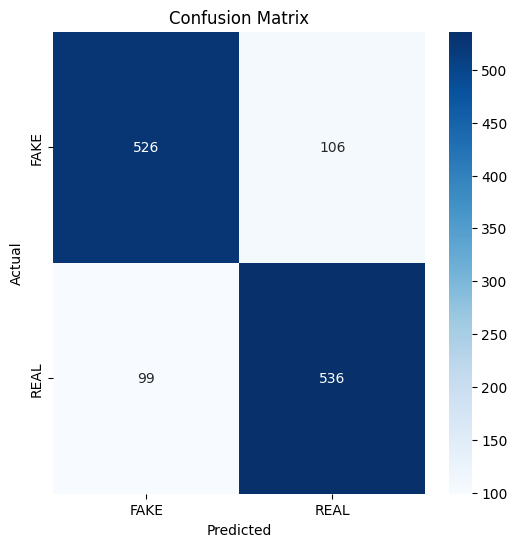

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Example: Calculate the confusion matrix
cm = confusion_matrix(y_test, predic_svm)

# Normalize the confusion matrix values to the range [0, 10]
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plotting the confusion matrix as a heatmap
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='0.0f', cmap='Blues', xticklabels=['FAKE', 'REAL'], yticklabels=['FAKE', 'REAL'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

KNN = KNeighborsClassifier()
KNN.fit(xe_train, y_train)

KNeighborsClassifier()

In [ ]:
predic_knn = KNN.predict(xe_test)

In [ ]:
KNN.score(xe_test, y_test)

0.7292817679558011

In [ ]:
from sklearn.tree import DecisionTreeClassifier

DTC = DecisionTreeClassifier()
DTC.fit(xe_train, y_train)

DecisionTreeClassifier()

In [ ]:
predic_dtc = DTC.predict(xe_test)

In [ ]:
DTC.score(xe_test, y_test)

0.7056037884767167

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

GBC = GradientBoostingClassifier()
GBC.fit(xe_train, y_train)

GradientBoostingClassifier()

In [ ]:
predic_gbc = GBC.predict(xe_test)

In [ ]:
GBC.score(xe_test, y_test)

0.813733228097869